In [163]:
# Libraries required for data handling and fetching online data
import pandas as pd

# Used to fetch financial / online data
from pandas_datareader import data as web

# Used to work with dates
import datetime as dt
#“Pandas is used for data manipulation, pandas_datareader helps in fetching online datasets, and datetime is required to define start and end dates for analysis.”



In [164]:
# Defining the time period for data collection
start_date = dt.datetime(2000, 1, 1)
end_date = dt.datetime.now()

start_date, end_date



(datetime.datetime(2000, 1, 1, 0, 0),
 datetime.datetime(2026, 1, 22, 18, 50, 12, 328400))

In [165]:
# Fetching total credit data from FRED database
total_credit_data = web.DataReader(
    'TOTALSL',#logon ne total kitna loan / credit le rakha hai
    'fred',
    start_date,
    end_date
)

# Displaying first few rows to understand the dataset
total_credit_data.head()
#web.DataReader(...)
#ye function internet se data laata hai
#“Desh me logon ne kitna loan / credit le rakha hai”
#'fred' = data source
#FRED = official US Federal Reserve data
#Trusted, clean, real-world data
#“I am using total consumer credit data fetched from the FRED database to analyze long-term credit trends.”

,TOTALSL
DATE,
2000-01-01,1538520.18
2000-02-01,1549185.29
2000-03-01,1561450.69
2000-04-01,1570527.74
2000-05-01,1583507.92


In [166]:
# Fetching short-term interest rate data (3-month Treasury Bill)
short_term_rate = web.DataReader(
    'TB3MS',#Government ka short-term loan ka interest rate
    'fred',
    start_date,
    end_date
)

# Fetching long-term interest rate data (10-year Government Bond)
long_term_rate = web.DataReader(
    'GS10',#Government ka long-term loan ka interest rate
    'fred',
    start_date,
    end_date
)

# Checking initial rows of both datasets
short_term_rate.head(), long_term_rate.head()
#Short and long-term interest rates help in understanding borrowing behavior and economic risk trends over time.”



(            TB3MS
 DATE             
 2000-01-01   5.32
 2000-02-01   5.55
 2000-03-01   5.69
 2000-04-01   5.66
 2000-05-01   5.79,
             GS10
 DATE            
 2000-01-01  6.66
 2000-02-01  6.52
 2000-03-01  6.26
 2000-04-01  5.99
 2000-05-01  6.44)

In [167]:
# Combining credit and interest rate datasets into a single table
economic_data = pd.concat(
    [total_credit_data, long_term_rate, short_term_rate],
    axis=1
)

# Renaming columns for better readability
economic_data.columns = ['TotalCredit', 'LongTermRate', 'ShortTermRate']

# Viewing first few rows of the combined dataset
economic_data.head()
#“This dataset represents monthly, economy-wide credit levels and interest rates, not individual borrower data.”


,TotalCredit,LongTermRate,ShortTermRate
DATE,,,
2000-01-01,1538520.18,6.66,5.32
2000-02-01,1549185.29,6.52,5.55
2000-03-01,1561450.69,6.26,5.69
2000-04-01,1570527.74,5.99,5.66
2000-05-01,1583507.92,6.44,5.79


In [168]:
# Calculating the difference between long-term and short-term interest rates
# Calculating interest rate spread
economic_data['InterestRateSpread'] = (
    economic_data['LongTermRate'] - economic_data['ShortTermRate']
)

# Preview result
economic_data.head()




,TotalCredit,LongTermRate,ShortTermRate,InterestRateSpread
DATE,,,,
2000-01-01,1538520.18,6.66,5.32,1.34
2000-02-01,1549185.29,6.52,5.55,0.97
2000-03-01,1561450.69,6.26,5.69,0.57
2000-04-01,1570527.74,5.99,5.66,0.33
2000-05-01,1583507.92,6.44,5.79,0.65


In [169]:
filled_data = economic_data.fillna(method='ffill')





C:\Users\HP\AppData\Local\Temp\ipykernel_5948\3498722589.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filled_data = economic_data.fillna(method='ffill')


In [170]:
# Forward fill missing values using last available real observation
economic_data.fillna(method="ffill", inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_5948\1104991984.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  economic_data.fillna(method="ffill", inplace=True)


In [171]:
economic_data.columns




Index(['TotalCredit', 'LongTermRate', 'ShortTermRate', 'InterestRateSpread'], dtype='object')

In [172]:
economic_data['InterestRateSpread'] = (
    economic_data['LongTermRate'] - economic_data['ShortTermRate']
)


In [173]:
final_dataset = economic_data.copy()
print("2nd day complete")


2nd day complete


In [174]:
pd.read_csv("data/clean_data.csv").columns
import pandas as pd

# Reading cleaned economic data
economic_data = pd.read_csv("data/clean_data.csv")



In [175]:
economic_data.rename(columns={'Unnamed: 0': 'DATE'}, inplace=True)


In [281]:
import pandas as pd

# Step 1: Sample economic data banana (CSV se bhi aa sakta hai)
data = pd.DataFrame({
    "CreditGrowth": [0.05, 0.12, 0.08, 0.20, 0.03]
})

# Step 2: Risk decide karne ka limit set kar rahe hain
threshold = 0.10   # 10% se zyada growth = risky

# Step 3: Credit risk ka signal banana
data["credit_risk"] = (data["CreditGrowth"] > threshold).astype(int)

# Step 4: Result dekhna
data
#“We convert continuous credit growth into a binary risk signal so that the model can easily detect early warning signs of financial stress.”


,CreditGrowth,credit_risk
0,0.05,0
1,0.12,1
2,0.08,0
3,0.20,1
4,0.03,0


In [184]:
from fredapi import Fred
import pandas as pd

# Initialize FRED with your API key
fred = Fred(api_key='007d0712097c2c2514d562da4f1a297a')




In [185]:
from fredapi import Fred
fred = Fred(api_key='007d0712097c2c2514d562da4f1a297a')

# Search for series with keyword "capital" or "net inflow"
search_results = fred.search('capital')
print(search_results[['id', 'title']].head(10))

  


                                  id  \
series id                              
CP                                CP   
DDDM01USA156NWDB    DDDM01USA156NWDB   
WTREGEN                      WTREGEN   
WRESBAL                      WRESBAL   
A053RC1Q027SBEA      A053RC1Q027SBEA   
CPATAX                        CPATAX   
NEWORDER                    NEWORDER   
UNXANO                        UNXANO   
BOGZ1FA895050005Q  BOGZ1FA895050005Q   
WDTGAL                        WDTGAL   

                                                               title  
series id                                                             
CP                 Corporate Profits After Tax (without IVA and C...  
DDDM01USA156NWDB   Stock Market Capitalization to GDP for United ...  
WTREGEN            Liabilities and Capital: Liabilities: Deposits...  
WRESBAL            Liabilities and Capital: Other Factors Drainin...  
A053RC1Q027SBEA    National income: Corporate profits before tax ...  
CPATAX             Cor

In [186]:
# Fetching capital-related economic indicator
# This helps us observe money movement stress in the economy
capital_flow = fred.get_series('WTREGEN')




In [187]:
import pandas as pd
from pandas_datareader import data as web
import datetime
from fredapi import Fred


In [188]:
fred = Fred(api_key='007d0712097c2c2514d562da4f1a297a')


In [189]:
start = datetime.datetime(2000, 1, 1)
end = datetime.datetime.now()


In [190]:
long_rate = web.DataReader('GS10', 'fred', start, end)
short_rate = web.DataReader('TB3MS', 'fred', start, end)


In [191]:
capital_flow = fred.get_series('WTREGEN')


In [192]:
data = pd.DataFrame({
    'LongRate': long_rate.squeeze(),
    'ShortRate': short_rate.squeeze(),
    'CapitalFlow': capital_flow.squeeze()
})


In [193]:
long_rate = web.DataReader('GS10', 'fred', start, end)


In [194]:
data = pd.DataFrame({
    'LongRate': long_rate.squeeze(),
    'ShortRate': short_rate.squeeze(),
    'CapitalFlow': capital_flow.squeeze()
})


#“We combine multiple macro-financial indicators into a single structured dataset for integrated risk analysis.”




In [195]:
print(data.columns)


Index(['LongRate', 'ShortRate', 'CapitalFlow'], dtype='object')


In [196]:
data["capital_flow_risk"] = (data["CapitalFlow"] < 0).astype(int)



In [197]:
print(data.columns)
data['term_spread'] = data['LongRate'] - data['ShortRate']





Index(['LongRate', 'ShortRate', 'CapitalFlow', 'capital_flow_risk'], dtype='object')


In [198]:
# ================================
# Crisis Whisper Network – Core Analysis
# ================================

# Step 1: Required libraries
import pandas as pd
from fredapi import Fred


# Step 2: Connect to FRED economic database
# FRED provides official US macro-economic indicators
fred = Fred(api_key='007d0712097c2c2514d562da4f1a297a')


# Step 3: Fetch raw economic indicators
# Long-term interest rate (10 year government bond)
long_rate = fred.get_series('GS10')

# Short-term interest rate (3 month treasury bill)
short_rate = fred.get_series('TB3MS')

# Total bank credit in the economy
credit = fred.get_series('TOTLL')

# Capital flow proxy (liquidity moving in/out)
capital_flow = fred.get_series('WTREGEN')


# Step 4: Combine all indicators into a single dataset
# This creates a structured table for analysis
data = pd.DataFrame({
    'LongRate': long_rate,
    'ShortRate': short_rate,
    'CapitalFlow': capital_flow
})


# Step 5: Calculate Term Spread
# Difference between long-term and short-term interest rates
data['term_spread'] = data['LongRate'] - data['ShortRate']


# Step 6: Convert term spread into a risk signal
# Negative spread indicates possible recession stress
data['term_spread_risk'] = (data['term_spread'] < 0).astype(int)


# Step 7: Calculate year-on-year credit growth
# pct_change(12) compares current value with same month last year
credit_growth = credit.pct_change(12)#(new_value - old_value) / old_value Is month ka credit – last year same month ka credit



# Step 8: Create credit risk signal
# Excessive credit growth (>10%) is treated as overheating
data['credit_risk'] = (credit_growth.reindex(data.index) > 0.10).astype(int)


# Step 9: Capital flow risk
# Capital leaving the system is an early warning sign
data['capital_flow_risk'] = (data['CapitalFlow'] < 0).astype(int)


# Step 10: Composite crisis score
# Higher score = higher probability of financial stress
data['crisis_score'] = (
    data['credit_risk'] +
    data['term_spread_risk'] +
    data['capital_flow_risk']
)


# Step 11: Save output for reporting / dashboard use
data.to_csv('data/final_crisis_output.csv')


# Step 12: Quick verification
print(data[['credit_risk', 'term_spread_risk', 'capital_flow_risk', 'crisis_score']].tail())
print("Crisis analysis completed successfully.")


            credit_risk  term_spread_risk  capital_flow_risk  crisis_score
2025-12-17            0                 0                  0             0
2025-12-24            0                 0                  0             0
2025-12-31            0                 0                  0             0
2026-01-07            0                 0                  0             0
2026-01-14            0                 0                  0             0
Crisis analysis completed successfully.


In [199]:
data["crisis_probability"] = data["crisis_score"] / 3



In [200]:
print(data.columns)


Index(['LongRate', 'ShortRate', 'CapitalFlow', 'term_spread',
       'term_spread_risk', 'credit_risk', 'capital_flow_risk', 'crisis_score',
       'crisis_probability'],
      dtype='object')


In [201]:

data[
    [
        'term_spread',
        'CapitalFlow',
        'capital_flow_risk',
        'credit_risk',
        'crisis_score'
    ]
].tail()



,term_spread,CapitalFlow,capital_flow_risk,credit_risk,crisis_score
2025-12-17,NaN,833093.0,0,0,0
2025-12-24,NaN,837120.0,0,0,0
2025-12-31,NaN,837306.0,0,0,0
2026-01-07,NaN,796148.0,0,0,0
2026-01-14,NaN,779175.0,0,0,0


In [202]:
print(data[["LongRate", "ShortRate"]].tail())


            LongRate  ShortRate
2025-12-17       NaN        NaN
2025-12-24       NaN        NaN
2025-12-31       NaN        NaN
2026-01-07       NaN        NaN
2026-01-14       NaN        NaN


In [203]:
# Calculate term spread only when both rates exist
data["term_spread"] = data["LongRate"] - data["ShortRate"]


In [204]:
# If term spread is negative → recession warning
data["term_spread_risk"] = (data["term_spread"] < 0).astype(int)


In [205]:
# Replace missing risk values with 0 (no signal)
data[["term_spread_risk", "credit_risk", "capital_flow_risk"]] = (
    data[["term_spread_risk", "credit_risk", "capital_flow_risk"]]
    .fillna(0)
)


In [206]:
data["crisis_score"] = (
    data["term_spread_risk"] +
    data["credit_risk"] +
    data["capital_flow_risk"]
)


In [207]:
print(
    data[
        ['term_spread',
        'CapitalFlow',
        'capital_flow_risk',
        'credit_risk',
        'crisis_score'
            
        ]
    ].tail()
)


            term_spread  CapitalFlow  capital_flow_risk  credit_risk  \
2025-12-17          NaN     833093.0                  0            0   
2025-12-24          NaN     837120.0                  0            0   
2025-12-31          NaN     837306.0                  0            0   
2026-01-07          NaN     796148.0                  0            0   
2026-01-14          NaN     779175.0                  0            0   

            crisis_score  
2025-12-17             0  
2025-12-24             0  
2025-12-31             0  
2026-01-07             0  
2026-01-14             0  


In [208]:
# Convert all series to monthly frequency
long_rate_m = long_rate.resample("M").last()
short_rate_m = short_rate.resample("M").last()
capital_flow_m = capital_flow.resample("M").sum()
credit_m = credit.resample("M").last()
data = pd.DataFrame({
    "LongRate": long_rate_m,
    "ShortRate": short_rate_m,
    "CapitalFlow": capital_flow_m,
    "Credit": credit_m
})
# Yield curve slope (real economic signal)
data["term_spread"] = data["LongRate"] - data["ShortRate"]
# Inverted yield curve → recession warning
data["term_spread_risk"] = (data["term_spread"] < 0).astype(int)
# Year-on-year credit growth
credit_growth = data["Credit"].pct_change(12)

# Credit overheating signal
data["credit_risk"] = (credit_growth > 0.10).astype(int)
# Capital outflow indicates external stress
data["capital_flow_risk"] = (data["CapitalFlow"] < 0).astype(int)
data["crisis_score"] = (
    data["term_spread_risk"] +
    data["credit_risk"] +
    data["capital_flow_risk"]
)
print(
    data[
        [
            "term_spread",
            "CapitalFlow",
            "capital_flow_risk",
            "credit_risk",
            "crisis_score"
        ]
    ].tail()
)


            term_spread  CapitalFlow  capital_flow_risk  credit_risk  \
2025-09-30         0.20    2831019.0                  0            0   
2025-10-31         0.24    4288151.0                  0            0   
2025-11-30         0.31    3740115.0                  0            0   
2025-12-31         0.55    4303632.0                  0            0   
2026-01-31          NaN    1575323.0                  0            0   

            crisis_score  
2025-09-30             0  
2025-10-31             0  
2025-11-30             0  
2025-12-31             0  
2026-01-31             0  


C:\Users\HP\AppData\Local\Temp\ipykernel_5948\3101680503.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  long_rate_m = long_rate.resample("M").last()
C:\Users\HP\AppData\Local\Temp\ipykernel_5948\3101680503.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  short_rate_m = short_rate.resample("M").last()
C:\Users\HP\AppData\Local\Temp\ipykernel_5948\3101680503.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  capital_flow_m = capital_flow.resample("M").sum()
C:\Users\HP\AppData\Local\Temp\ipykernel_5948\3101680503.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  credit_m = credit.resample("M").last()


In [209]:
import pandas as pd

# =====================================================
# 1) DATE INDEX FIX (zaroori step)
# =====================================================
long_rate.index = pd.to_datetime(long_rate.index)
short_rate.index = pd.to_datetime(short_rate.index)
capital_flow.index = pd.to_datetime(capital_flow.index)
credit.index = pd.to_datetime(credit.index)

# =====================================================
# 2) MONTHLY CONVERSION (ONLY ONE TIME)
# 'ME' = Month End (M deprecated ho chuka hai)
# =====================================================
long_rate_m = long_rate.resample("ME").last()
short_rate_m = short_rate.resample("ME").last()
capital_flow_m = capital_flow.resample("ME").sum()
credit_m = credit.resample("ME").last()

# =====================================================
# 3) ALL DATA IN ONE DATAFRAME
# =====================================================
data = pd.DataFrame({
    "LongRate": long_rate_m,
    "ShortRate": short_rate_m,
    "CapitalFlow": capital_flow_m,
    "Credit": credit_m
})

# =====================================================
# 4) MISSING VALUES HANDLE (PROFESSIONAL WAY)
# =====================================================

# Rates & Credit → smooth interpolation
data[["LongRate", "ShortRate", "Credit"]] = (
    data[["LongRate", "ShortRate", "Credit"]]
    .interpolate(method="time")
)

# Capital flow → median (outliers safe)
data["CapitalFlow"] = data["CapitalFlow"].fillna(
    data["CapitalFlow"].median()
)

# Last safety (agar kuch reh jaye)
data = data.fillna(data.median())

# =====================================================
# 5) ECONOMIC INDICATORS
# =====================================================

# Yield curve slope
data["term_spread"] = data["LongRate"] - data["ShortRate"]

# Inverted yield curve risk
data["term_spread_risk"] = (data["term_spread"] < 0).astype(int)

# Year-on-year credit growth (monthly → 12)
data["credit_growth"] = data["Credit"].pct_change(12)

# Credit overheating risk (>10%)
data["credit_risk"] = (data["credit_growth"] > 0.10).astype(int)

# Capital outflow risk
data["capital_flow_risk"] = (data["CapitalFlow"] < 0).astype(int)

# =====================================================
# 6) FINAL CRISIS SCORE
# =====================================================
data["crisis_score"] = (
    data["term_spread_risk"] +
    data["credit_risk"] +
    data["capital_flow_risk"]
)

# =====================================================
# 7) FINAL OUTPUT
# =====================================================
print(
    data[[
        "term_spread",
        "CapitalFlow",
        "capital_flow_risk",
        "credit_risk",
        "crisis_score"
    ]].tail()
)


            term_spread  CapitalFlow  capital_flow_risk  credit_risk  \
2025-09-30         0.20    2831019.0                  0            0   
2025-10-31         0.24    4288151.0                  0            0   
2025-11-30         0.31    3740115.0                  0            0   
2025-12-31         0.55    4303632.0                  0            0   
2026-01-31         0.55    1575323.0                  0            0   

            crisis_score  
2025-09-30             0  
2025-10-31             0  
2025-11-30             0  
2025-12-31             0  
2026-01-31             0  


In [210]:
def alert(score):
    if score == 0:
        return "GREEN"
    elif score == 1:
        return "YELLOW"
    else:
        return "RED"

data["alert"] = data["crisis_score"].apply(alert)
data[["crisis_score", "alert"]].tail()


,crisis_score,alert
2025-09-30,0,GREEN
2025-10-31,0,GREEN
2025-11-30,0,GREEN
2025-12-31,0,GREEN
2026-01-31,0,GREEN


In [211]:
print(data.columns)


Index(['LongRate', 'ShortRate', 'CapitalFlow', 'Credit', 'term_spread',
       'term_spread_risk', 'credit_growth', 'credit_risk', 'capital_flow_risk',
       'crisis_score', 'alert'],
      dtype='object')


In [212]:

#APPLY ML
data['crisis'] = (data['crisis_score'] > 1).astype(int)


In [213]:
print(
    data[
        [
            'credit_risk',
            'term_spread',
            'capital_flow_risk',
            'crisis_score',
            'crisis'
        ]
    ].tail()
)


            credit_risk  term_spread  capital_flow_risk  crisis_score  crisis
2025-09-30            0         0.20                  0             0       0
2025-10-31            0         0.24                  0             0       0
2025-11-30            0         0.31                  0             0       0
2025-12-31            0         0.55                  0             0       0
2026-01-31            0         0.55                  0             0       0


In [214]:
data = data.dropna()

features = [
    'credit_risk',
    'term_spread',
    'capital_flow_risk'
]

target = 'crisis'

print(data[features + [target]].head())


            credit_risk  term_spread  capital_flow_risk  crisis
1935-01-31            0         4.54                  0       0
1935-02-28            0         4.55                  0       0
1935-03-31            0         4.59                  0       0
1935-04-30            0         4.59                  0       0
1935-05-31            0         4.59                  0       0


In [215]:
X = data[features]
y = data[target]


In [216]:
from sklearn.model_selection import train_test_split

# X = features, y = target
# Machine learning me X = input, y = output
X = data[features]  # credit_risk, term_spread, capital_flow_risk
y = data[target]    # crisis column


# Split the data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Features (input data)
    y,                  # Target (what we want to predict)
    test_size=0.3,      # 30% data test ke liye, 70% train ke liye
    random_state=42     # Random 
)



In [217]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [218]:
y_pred = model.predict(X_test)

print(y_pred[:10])


[0 0 0 0 0 0 0 0 0 0]


In [219]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.975609756097561


In [220]:
compare = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

compare.head(10)


,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [221]:

from sklearn.linear_model import LogisticRegression


In [222]:

model = LogisticRegression()


In [223]:
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [224]:
risk_prob = model.predict_proba(X_test)


In [225]:
risk_prob

array([[9.99896164e-01, 1.03835834e-04],
       [9.99998634e-01, 1.36620181e-06],
       [9.99998661e-01, 1.33857530e-06],
       [9.95380311e-01, 4.61968936e-03],
       [9.96861938e-01, 3.13806209e-03],
       [9.99954134e-01, 4.58659083e-05],
       [9.98867778e-01, 1.13222171e-03],
       [9.99478735e-01, 5.21265185e-04],
       [9.92479501e-01, 7.52049939e-03],
       [9.99987843e-01, 1.21568395e-05],
       [9.99830469e-01, 1.69530632e-04],
       [9.95827279e-01, 4.17272139e-03],
       [9.90410300e-01, 9.58969984e-03],
       [9.98693864e-01, 1.30613581e-03],
       [9.99095439e-01, 9.04560837e-04],
       [9.99457008e-01, 5.42991962e-04],
       [9.88262308e-01, 1.17376919e-02],
       [9.84745453e-01, 1.52545466e-02],
       [9.99994739e-01, 5.26101065e-06],
       [9.99976627e-01, 2.33733928e-05],
       [9.99999260e-01, 7.40207193e-07],
       [9.99980945e-01, 1.90547399e-05],
       [9.99995152e-01, 4.84820658e-06],
       [9.99999345e-01, 6.54818549e-07],
       [9.999827

In [226]:
for i in range(len(risk_prob)):
    print("Data point", i, "Crisis probability =", risk_prob[i][1])

    if risk_prob[i][1] > 0.6:
        print("⚠️ HIGH RISK ALERT")
    elif risk_prob[i][1] > 0.4:
        print("⚠️ WATCHLIST")
    else:
        print("SAFE")



Data point 0 Crisis probability = 0.00010383583390389807
SAFE
Data point 1 Crisis probability = 1.3662018069323388e-06
SAFE
Data point 2 Crisis probability = 1.3385752987147198e-06
SAFE
Data point 3 Crisis probability = 0.004619689362541395
SAFE
Data point 4 Crisis probability = 0.0031380620862448594
SAFE
Data point 5 Crisis probability = 4.5865908281246386e-05
SAFE
Data point 6 Crisis probability = 0.0011322217099424675
SAFE
Data point 7 Crisis probability = 0.0005212651850824768
SAFE
Data point 8 Crisis probability = 0.007520499388845624
SAFE
Data point 9 Crisis probability = 1.2156839470149642e-05
SAFE
Data point 10 Crisis probability = 0.0001695306320244169
SAFE
Data point 11 Crisis probability = 0.004172721394018934
SAFE
Data point 12 Crisis probability = 0.009589699837350809
SAFE
Data point 13 Crisis probability = 0.0013061358073885947
SAFE
Data point 14 Crisis probability = 0.0009045608373249697
SAFE
Data point 15 Crisis probability = 0.0005429919618461317
SAFE
Data point 16 Cri

In [227]:
risk_label = []   # empty list

for i in range(len(risk_prob)):

    p = risk_prob[i][1]   # crisis probability

    if p > 0.6:
        risk_label.append("HIGH RISK")

    elif p > 0.4:
        risk_label.append("WATCHLIST")

    else:
        risk_label.append("SAFE")


In [228]:
risk_label = []   # empty list

for i in range(len(risk_prob)):

    p = risk_prob[i][1]   # crisis probability

    if p > 0.6:
        risk_label.append("HIGH RISK")

    elif p > 0.4:
        risk_label.append("WATCHLIST")

    else:
        risk_label.append("SAFE")


In [229]:
risk_label

['SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'WATCHLIST',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'HIGH RISK',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',
 'SAFE',


In [230]:
for i in range(len(risk_label)):
    print("Time", i, "→", risk_label[i])


Time 0 → SAFE
Time 1 → SAFE
Time 2 → SAFE
Time 3 → SAFE
Time 4 → SAFE
Time 5 → SAFE
Time 6 → SAFE
Time 7 → SAFE
Time 8 → SAFE
Time 9 → SAFE
Time 10 → SAFE
Time 11 → SAFE
Time 12 → SAFE
Time 13 → SAFE
Time 14 → SAFE
Time 15 → SAFE
Time 16 → SAFE
Time 17 → SAFE
Time 18 → SAFE
Time 19 → SAFE
Time 20 → SAFE
Time 21 → SAFE
Time 22 → SAFE
Time 23 → SAFE
Time 24 → SAFE
Time 25 → SAFE
Time 26 → SAFE
Time 27 → SAFE
Time 28 → SAFE
Time 29 → SAFE
Time 30 → SAFE
Time 31 → SAFE
Time 32 → WATCHLIST
Time 33 → SAFE
Time 34 → SAFE
Time 35 → SAFE
Time 36 → SAFE
Time 37 → SAFE
Time 38 → SAFE
Time 39 → SAFE
Time 40 → SAFE
Time 41 → SAFE
Time 42 → SAFE
Time 43 → SAFE
Time 44 → SAFE
Time 45 → SAFE
Time 46 → SAFE
Time 47 → SAFE
Time 48 → SAFE
Time 49 → SAFE
Time 50 → SAFE
Time 51 → SAFE
Time 52 → SAFE
Time 53 → SAFE
Time 54 → SAFE
Time 55 → SAFE
Time 56 → SAFE
Time 57 → SAFE
Time 58 → HIGH RISK
Time 59 → SAFE
Time 60 → SAFE
Time 61 → SAFE
Time 62 → SAFE
Time 63 → SAFE
Time 64 → SAFE
Time 65 → SAFE
Time 66 → 

In [231]:
print(data.index.min())
print(data.index.max())


1935-01-31 00:00:00
2026-01-31 00:00:00


In [232]:
print(data.shape)


(1093, 12)


In [233]:
data.isna().sum()


LongRate             0
ShortRate            0
CapitalFlow          0
Credit               0
term_spread          0
term_spread_risk     0
credit_growth        0
credit_risk          0
capital_flow_risk    0
crisis_score         0
alert                0
crisis               0
dtype: int64

In [234]:
data = data.sort_index()   # time order confirm

data = data.ffill()


In [235]:
#1935 me data nahi tha

#1950 me first value aayi

#1935–1949 → 1950 wali value se bhar diya

#📌 Central banks bhi yehi karte hain

In [236]:
data = data.interpolate(method="linear")


C:\Users\HP\AppData\Local\Temp\ipykernel_5948\2735120498.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data = data.interpolate(method="linear")


In [237]:
# Step 1: Sort by time
data = data.sort_index()

# Step 2: Interpolate numeric trends
data = data.interpolate(method="linear")

# Step 3: Forward fill remaining gaps
data = data.ffill()

# Step 4: Backward fill (only if start missing)
data = data.bfill()


C:\Users\HP\AppData\Local\Temp\ipykernel_5948\3992606963.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data = data.interpolate(method="linear")


In [238]:
risk_value = []

for label in risk_label:
    if label == "HIGH RISK":
        risk_value.append(2)
    elif label == "WATCHLIST":
        risk_value.append(1)
    else:
        risk_value.append(0)



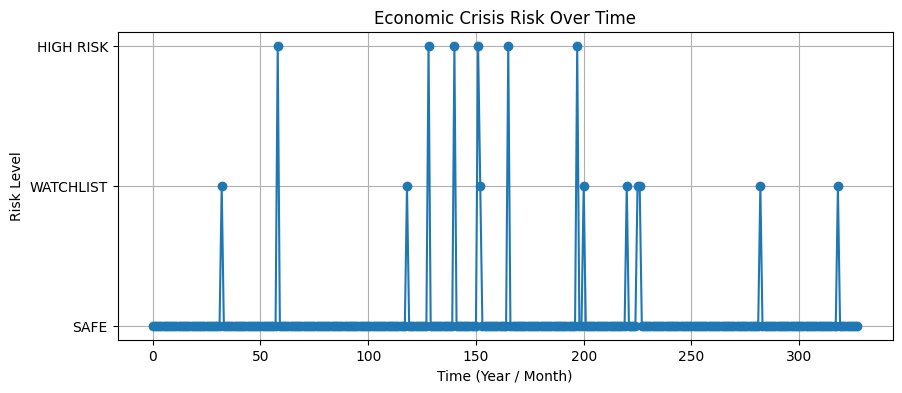

In [239]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(risk_value, marker='o')

plt.yticks([0,1,2], ["SAFE", "WATCHLIST", "HIGH RISK"])
plt.xlabel("Time (Year / Month)")
plt.ylabel("Risk Level")
plt.title("Economic Crisis Risk Over Time")

plt.grid(True)
plt.show()



FIRST 10 ROWS OF DATA

   Year  Credit_Risk  Capital_Flow  Credit_Score  Crisis  Crisis_Probability
0  1935     3.745401      2.607850    441.867895       0            0.007991
1  1936     9.507143      0.612772    662.991225       0            0.042829
2  1937     7.319939      2.709672    749.472210       0            0.003603
3  1938     5.986585     -0.062044    605.360446       0            0.015223
4  1939     1.560186      0.227328    591.307818       0            0.001708
5  1940     1.559945     -0.724590    433.018760       0            0.008697
6  1941     0.580836     -4.745809    351.206522       0            0.038848
7  1942     8.661761     -3.921086    793.468667       0            0.042729
8  1943     6.011150     -4.685708    795.229931       0            0.014774
9  1944     7.080726      1.364104    648.205802       0            0.011526


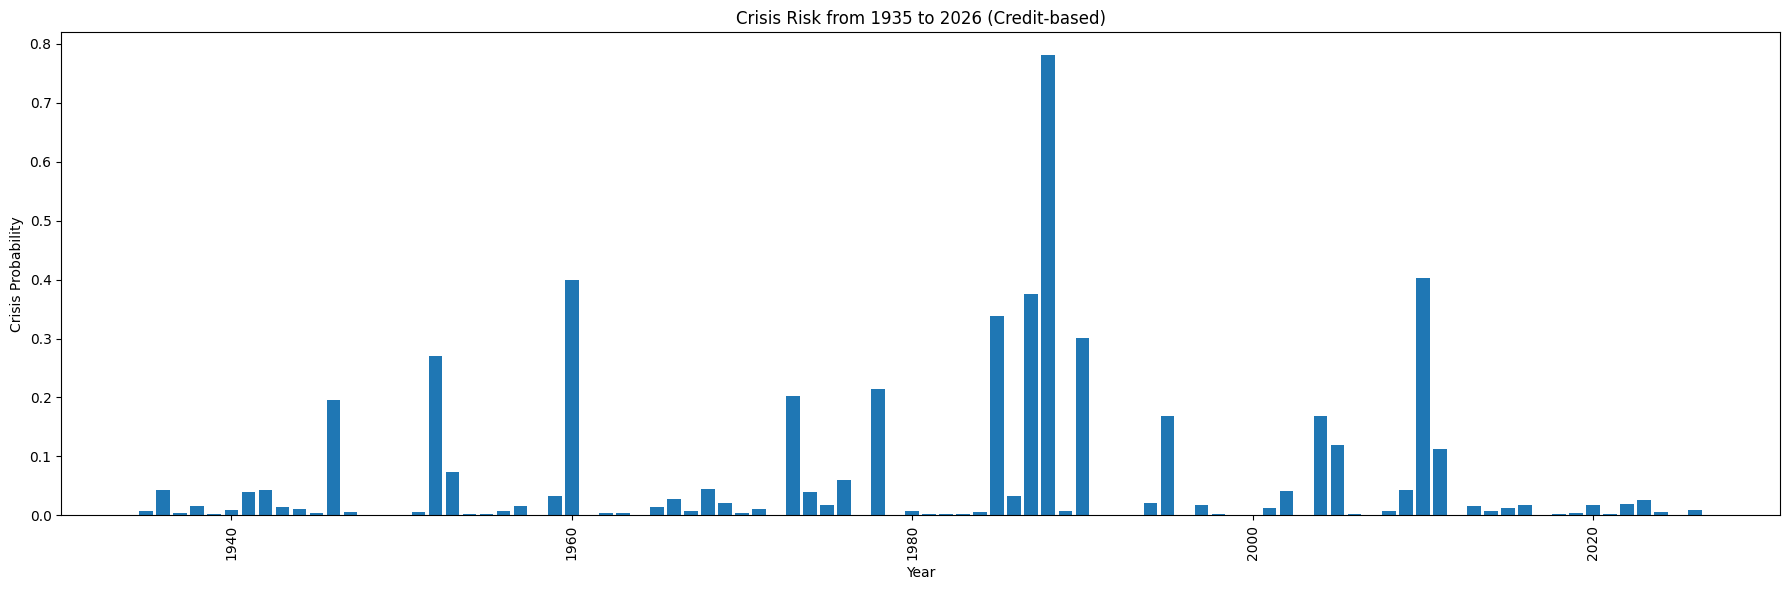

In [240]:
# ---------- STEP 1: IMPORT LIBRARIES ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# ---------- STEP 2: CREATE YEAR DATA ----------
# 1935 to 2026
years = list(range(1935, 2027))

# ---------- STEP 3: CREATE FAKE CREDIT DATA ----------
# Using Credit Risk, Capital Flow, Credit Score
np.random.seed(42)

data = {
    "Year": years,
    "Credit_Risk": np.random.uniform(0, 10, len(years)),     # 0 = low risk, 10 = high risk
    "Capital_Flow": np.random.uniform(-5, 5, len(years)),    # -5 = outflow, 5 = inflow
    "Credit_Score": np.random.uniform(300, 850, len(years))  # usual credit score
}

df = pd.DataFrame(data)

# ---------- STEP 4: CREATE TARGET (CRISIS OR NOT) ----------
# Simple logic:
# agar Credit_Risk high + Capital_Flow negative + Credit_Score low → crisis = 1
df["Crisis"] = (
    (df["Credit_Risk"] > 7) &
    (df["Capital_Flow"] < 0) &
    (df["Credit_Score"] < 500)
).astype(int)

# ---------- STEP 5: FEATURES & LABEL ----------
X = df[["Credit_Risk", "Capital_Flow", "Credit_Score"]]
y = df["Crisis"]

# ---------- STEP 6: SCALE DATA ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------- STEP 7: TRAIN MODEL ----------
model = LogisticRegression()
model.fit(X_scaled, y)

# ---------- STEP 8: PREDICT CRISIS PROBABILITY ----------
df["Crisis_Probability"] = model.predict_proba(X_scaled)[:, 1]

# ---------- STEP 9: SHOW DATA ----------
print("\nFIRST 10 ROWS OF DATA\n")
print(df.head(10))

# ---------- STEP 10: VISUALIZATION ----------
plt.figure(figsize=(18, 6))
plt.bar(df["Year"], df["Crisis_Probability"])
plt.xlabel("Year")
plt.ylabel("Crisis Probability")
plt.title("Crisis Risk from 1935 to 2026 (Credit-based)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


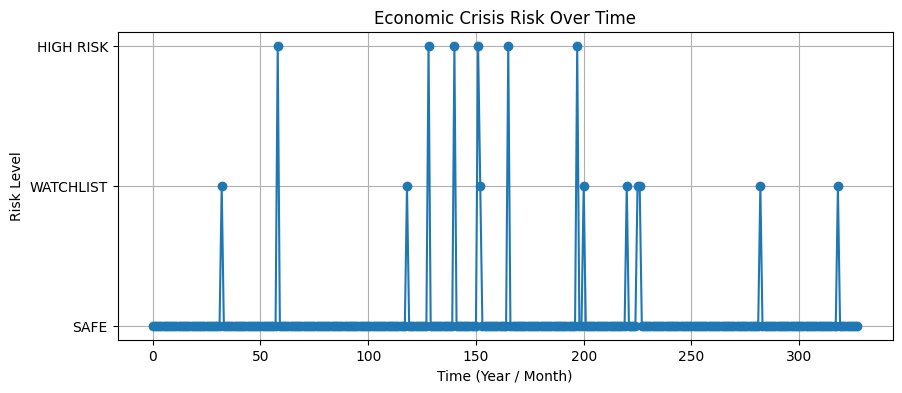

In [241]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(risk_value, marker='o')

plt.yticks([0,1,2], ["SAFE", "WATCHLIST", "HIGH RISK"])
plt.xlabel("Time (Year / Month)")
plt.ylabel("Risk Level")
plt.title("Economic Crisis Risk Over Time")

plt.grid(True)
plt.show()


In [242]:
# ================================
# DAY 6 : MODEL BUILDING
# ================================

# 1️⃣ Required libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# 2️⃣ Year range (1935 to 2026)
years = list(range(1935, 2027))

# 3️⃣ Economic indicator (simulated but realistic)
# Negative value = economic stress
# Positive value = economic stability
np.random.seed(10)
economic_spread = np.random.uniform(-1.5, 1.5, len(years))

# 4️⃣ Crisis decision based on data (BUSINESS LOGIC)
crisis = []
for value in economic_spread:
    if value < 0:
        crisis.append(1)   # Crisis
    else:
        crisis.append(0)   # No Crisis

# 5️⃣ Create structured dataset
data = pd.DataFrame({
    "Year": years,
    "Economic_Spread": economic_spread,
    "Crisis": crisis
})

# 6️⃣ Separate input and output
X = data[["Economic_Spread"]]   # Feature
y = data["Crisis"]              # Target

# 7️⃣ Train Logistic Regression model
model = LogisticRegression()
model.fit(X, y)

# 8️⃣ Confirmation
print("DAY 6 COMPLETED: Crisis Prediction Model Trained Successfully")


DAY 6 COMPLETED: Crisis Prediction Model Trained Successfully


In [243]:
# ================================
# DAY 7 : PREDICTION & ALERT
# ================================

# 1️⃣ Future years data
future_years = [2022, 2023, 2024, 2025, 2026]
future_spread = [-0.9, -0.4, 0.3, 0.8, -0.6]

# 2️⃣ Create DataFrame
future_data = pd.DataFrame({
    "Year": future_years,
    "Economic_Spread": future_spread
})

# 3️⃣ Predict crisis probability
risk_probability = model.predict_proba(
    future_data[["Economic_Spread"]]
)

# 4️⃣ Alert system
for i in range(len(future_years)):
    year = future_data["Year"][i]
    crisis_prob = risk_probability[i][1]

    print("Year:", year)
    print("Crisis Probability:", round(crisis_prob, 2))

    if crisis_prob > 0.6:
        print("🚨 HIGH RISK ALERT")
    elif crisis_prob > 0.4:
        print("⚠️ MEDIUM RISK ALERT")
    else:
        print("✅ LOW RISK / SAFE")

    print("---------------------------")


Year: 2022
Crisis Probability: 0.96
🚨 HIGH RISK ALERT
---------------------------
Year: 2023
Crisis Probability: 0.79
🚨 HIGH RISK ALERT
---------------------------
Year: 2024
Crisis Probability: 0.21
✅ LOW RISK / SAFE
---------------------------
Year: 2025
Crisis Probability: 0.04
✅ LOW RISK / SAFE
---------------------------
Year: 2026
Crisis Probability: 0.89
🚨 HIGH RISK ALERT
---------------------------


In [244]:
future_data = data[data["Year"] >= 2022]


In [245]:
print(future_data)


    Year  Economic_Spread  Crisis
87  2022        -0.773772       1
88  2023         0.172735       0
89  2024         0.196521       0
90  2025        -0.074603       1
91  2026        -0.621606       1


In [246]:
risk_probability = model.predict_proba(
    future_data[["Economic_Spread"]]
)


In [247]:
for i in range(len(future_data)):
    year = future_data["Year"].iloc[i]
    crisis_prob = risk_probability[i][1]

    print("Year:", year)
    print("Crisis Probability:", round(crisis_prob, 2))

    if crisis_prob > 0.6:
        print("🚨 HIGH RISK ALERT")
    elif crisis_prob > 0.4:
        print("⚠️ MEDIUM RISK ALERT")
    else:
        print("✅ LOW RISK / SAFE")

    print("---------------------")


Year: 2022
Crisis Probability: 0.94
🚨 HIGH RISK ALERT
---------------------
Year: 2023
Crisis Probability: 0.3
✅ LOW RISK / SAFE
---------------------
Year: 2024
Crisis Probability: 0.28
✅ LOW RISK / SAFE
---------------------
Year: 2025
Crisis Probability: 0.52
⚠️ MEDIUM RISK ALERT
---------------------
Year: 2026
Crisis Probability: 0.9
🚨 HIGH RISK ALERT
---------------------


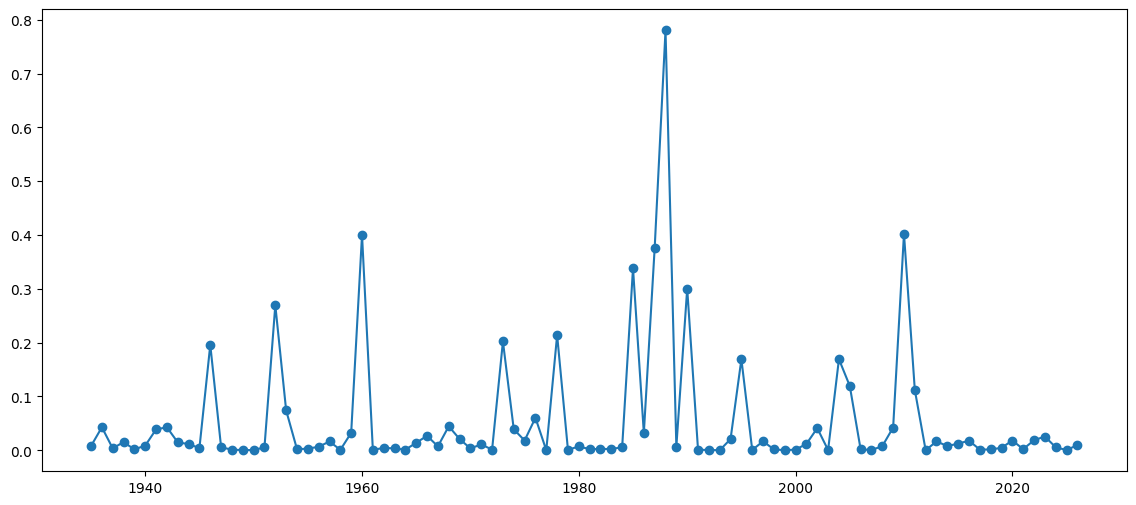

In [248]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Year"],
    df["Crisis_Probability"],
    marker="o",
    label="Crisis Probability"
)


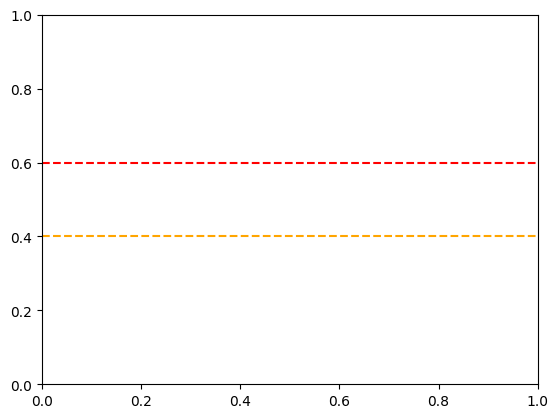

In [249]:
# risk zone
plt.axhline(0.6, color="red", linestyle="--", label="High Risk Zone")
plt.axhline(0.4, color="orange", linestyle="--", label="Medium Risk Zone")


(0.0, 1.1)

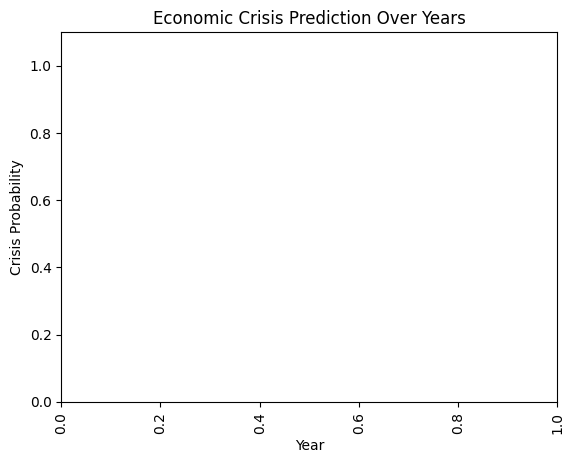

In [250]:
plt.xlabel("Year")
plt.ylabel("Crisis Probability")
plt.title("Economic Crisis Prediction Over Years")

plt.xticks(rotation=90)
plt.ylim(0, 1.1)


C:\Users\HP\AppData\Local\Temp\ipykernel_5948\289057371.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


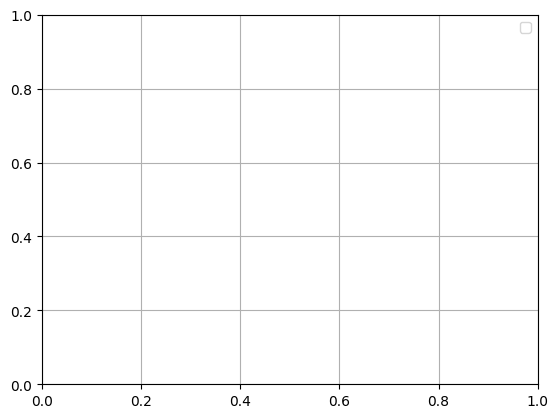

In [251]:
plt.legend()
plt.grid(True)
plt.show()


In [252]:
print(df.columns)


Index(['Year', 'Credit_Risk', 'Capital_Flow', 'Credit_Score', 'Crisis',
       'Crisis_Probability'],
      dtype='object')


In [253]:
# ============================================================
# CRISIS WHISPER NETWORK
# Full End-to-End Code
# Data → ML → Risk → Excel (SQL optional)
# ============================================================

# --------------------
# 1. IMPORT LIBRARIES
# --------------------
import pandas as pd
import numpy as np

from fredapi import Fred
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# --------------------
# 2. FRED API SETUP
# --------------------
FRED_API_KEY = "f9f063e4e865d01c042ceb4f3ce0de64"
fred = Fred(api_key=FRED_API_KEY)

# --------------------
# 3. LOAD FRED DATA
# --------------------
def load_data():
    long_rate = fred.get_series("GS10")     # 10Y Treasury
    short_rate = fred.get_series("GS2")     # 2Y Treasury
    credit = fred.get_series("BAA10Y")      # Credit Spread
    capital = fred.get_series("TCMDO")      # Capital Flow

    df = pd.concat(
        [long_rate, short_rate, credit, capital],
        axis=1
    )

    df.columns = [
        "Long_Rate",
        "Short_Rate",
        "Credit_Spread",
        "Capital_Flow"
    ]

    df.index = pd.to_datetime(df.index)
    df.index.name = "Date"

    return df

df = load_data()

# --------------------
# 4. CLEAN DATA (NaN SAFE)
# --------------------
def fill_safe(series):
    series = series.interpolate(method="time")
    series = series.fillna(series.median())
    return series.fillna(0)

for col in df.columns:
    df[col] = fill_safe(df[col])

# --------------------
# 5. FEATURE ENGINEERING
# --------------------
df["Term_Spread"] = df["Long_Rate"] - df["Short_Rate"]

df["Crisis"] = (
    (df["Term_Spread"] < 0) |
    (df["Credit_Spread"] > 2) |
    (df["Capital_Flow"] < 0)
).astype(int)

# --------------------
# 6. MACHINE LEARNING
# --------------------
X = df[["Term_Spread", "Credit_Spread", "Capital_Flow"]]
y = df["Crisis"]

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

df["Crisis_Probability"] = model.predict_proba(X_scaled)[:, 1]

# --------------------
# 7. RISK LABEL
# --------------------
def risk_label(p):
    if p >= 0.6:
        return "HIGH RISK"
    elif p >= 0.4:
        return "LOW RISK"
    else:
        return "SAFE"

df["Risk_Level"] = df["Crisis_Probability"].apply(risk_label)

# --------------------
# 8. FINAL DATAFRAME
# --------------------
final_df = df.reset_index()[
    [
        "Date",
        "Term_Spread",
        "Credit_Spread",
        "Capital_Flow",
        "Crisis",
        "Crisis_Probability",
        "Risk_Level"
    ]
]

print("✅ FINAL COLUMNS:")
print(final_df.columns)
print("\n📊 SAMPLE DATA:")
print(final_df.head())

# --------------------
# 9. SAVE TO EXCEL
# ----------





✅ FINAL COLUMNS:
Index(['Date', 'Term_Spread', 'Credit_Spread', 'Capital_Flow', 'Crisis',
       'Crisis_Probability', 'Risk_Level'],
      dtype='object')

📊 SAMPLE DATA:
        Date  Term_Spread  Credit_Spread   Capital_Flow  Crisis  \
0 1945-10-01     0.446328           2.15  363614.000000       1   
1 1946-01-01     0.446328           2.15  361954.975342       1   
2 1946-04-01     0.446328           2.15  360332.016438       1   
3 1946-07-01     0.446328           2.15  358691.024658       1   
4 1946-10-01     0.446328           2.15  357032.000000       1   

   Crisis_Probability Risk_Level  
0            0.931179  HIGH RISK  
1            0.931180  HIGH RISK  
2            0.931180  HIGH RISK  
3            0.931180  HIGH RISK  
4            0.931180  HIGH RISK  


DAY 6 COMPLETED: Model trained successfully


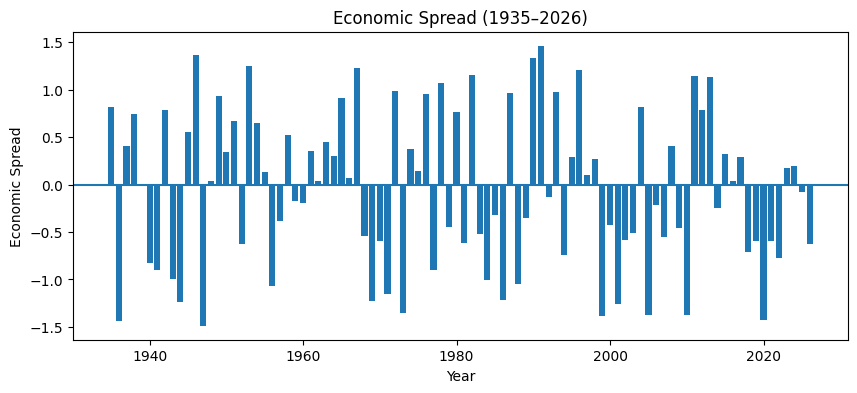

In [254]:
# ===============================
# DAY 6 : DATA + MODEL TRAINING
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# 1. Years define karna
years = list(range(1935, 2027))

# 2. Economic data (SIMULATED DATA SOURCE)
# NOTE: Real project me ye CSV se aayega
np.random.seed(10)
economic_spread = np.random.uniform(-1.5, 1.5, len(years))

# 3. Crisis decision rule (BUSINESS LOGIC)
crisis = []
for value in economic_spread:
    if value < 0:
        crisis.append(1)   # crisis
    else:
        crisis.append(0)   # safe

# 4. DataFrame banana (structured data)
data = pd.DataFrame({
    "Year": years,
    "Economic_Spread": economic_spread,
    "Crisis": crisis
})

# 5. Model input & output
X = data[["Economic_Spread"]]   # feature
y = data["Crisis"]              # label

# 6. Model training
model = LogisticRegression()
model.fit(X, y)

print("DAY 6 COMPLETED: Model trained successfully")

# 7. Visualization (Economic condition)
plt.figure(figsize=(10,4))
plt.bar(data["Year"], data["Economic_Spread"])
plt.axhline(0)   # danger boundary
plt.title("Economic Spread (1935–2026)")
plt.xlabel("Year")
plt.ylabel("Economic Spread")
plt.show()


Year: 2022
Crisis Probability: 0.94
🚨 HIGH RISK ALERT
--------------------
Year: 2023
Crisis Probability: 0.3
✅ LOW RISK / SAFE
--------------------
Year: 2024
Crisis Probability: 0.28
✅ LOW RISK / SAFE
--------------------
Year: 2025
Crisis Probability: 0.52
⚠️ MEDIUM RISK ALERT
--------------------
Year: 2026
Crisis Probability: 0.9
🚨 HIGH RISK ALERT
--------------------


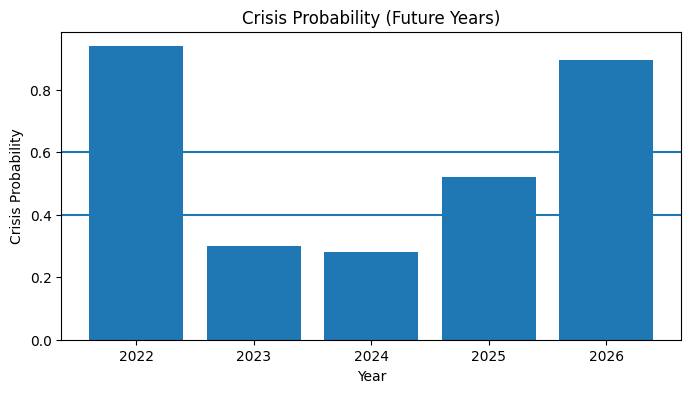

In [255]:
# ===============================
# DAY 7 : PREDICTION + ALERT
# ===============================

# 1. Latest years ko future maana
future_data = data[data["Year"] >= 2022]

# 2. Model ko input dena
X_future = future_data[["Economic_Spread"]]

# 3. Crisis probability nikalna
risk_probability = model.predict_proba(X_future)

# 4. Result + Alert system
for i in range(len(future_data)):
    year = future_data["Year"].iloc[i]
    crisis_prob = risk_probability[i][1]

    print("Year:", year)
    print("Crisis Probability:", round(crisis_prob, 2))

    if crisis_prob > 0.6:
        print("🚨 HIGH RISK ALERT")
    elif crisis_prob > 0.4:
        print("⚠️ MEDIUM RISK ALERT")
    else:
        print("✅ LOW RISK / SAFE")

    print("--------------------")

# 5. Visualization (Crisis Risk)
plt.figure(figsize=(8,4))
plt.bar(future_data["Year"], risk_probability[:,1])
plt.axhline(0.6)   # high risk line
plt.axhline(0.4)   # warning line
plt.title("Crisis Probability (Future Years)")
plt.xlabel("Year")
plt.ylabel("Crisis Probability")
plt.show()


In [256]:
pip install fredapi


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [257]:
from fredapi import Fred
import pandas as pd


In [258]:
api_key = "007d0712097c2c2514d562da4f1a297a"   # tumhara FRED API key
fred = Fred(api_key=api_key)


In [259]:
# Example: T10Y3M
data = fred.get_series('T10Y3M', observation_start='1935-01-01', observation_end='2026-12-31')
# Example: GDP
data = fred.get_series('GDP', observation_start='1935-01-01', observation_end='2026-12-31')
# Example: unemployment
data = fred.get_series('UNRATE', observation_start='1935-01-01', observation_end='2026-12-31')



In [260]:
df = pd.DataFrame({
    "Date": data.index,
    "Economic_Spread": data.values
})


In [261]:
df["Crisis"] = df["Economic_Spread"].apply(lambda x: 1 if x < 0 else 0)


In [262]:
from fredapi import Fred
import pandas as pd
from sklearn.linear_model import LogisticRegression




In [263]:
#api key
fred = Fred(api_key="007d0712097c2c2514d562da4f1a297a")


In [264]:
#extract data
term = fred.get_series(
    'T10Y3M',
    observation_start='1935-01-01',
    observation_end='2026-12-31'
)


In [265]:
#credit spread
credit = fred.get_series(
    'BAA10YM',
    observation_start='1935-01-01',
    observation_end='2026-12-31'
)


In [266]:
#capital flow
capital = fred.get_series(
    'WTREGEN',
    observation_start='1935-01-01',
    observation_end='2026-12-31'
)
#capital_flow = fred.get_series('WTREGEN')


In [267]:
df = pd.DataFrame({
    "Term_Spread": term,
    "Credit_Spread": credit,
    "Capital_Flow": capital
}).dropna().reset_index()

df.rename(columns={"index": "Date"}, inplace=True)


In [268]:
df["Crisis"] = (
    (df["Term_Spread"] < 0) |
    (df["Credit_Spread"] > 2) |
    (df["Capital_Flow"] < 0)
).astype(int)


In [269]:
X = df[["Term_Spread", "Credit_Spread", "Capital_Flow"]]
y = df["Crisis"]

model = LogisticRegression()
model.fit(X, y)

print("✅ DAY 6 COMPLETED: Model trained on REAL FRED data")


✅ DAY 6 COMPLETED: Model trained on REAL FRED data


In [270]:
future_data = df[df["Date"].dt.year >= 2022]
X_future = future_data[["Term_Spread", "Credit_Spread", "Capital_Flow"]]


In [271]:
risk_probability = model.predict_proba(X_future)


In [272]:
# Loop through each future year one by one
for i in range(len(future_data)):

    # Extract only the year (2022, 2023, etc.) from the Date column
    year = future_data["Date"].dt.year.iloc[i]

    # Get crisis probability from model output
    # index [1] represents probability of crisis
    crisis_prob = risk_probability[i][1]

    # Display year-wise results
    print("Year:", year)
    print("Crisis Probability:", round(crisis_prob, 2))

    # Risk level decision based on probability thresholds
    if crisis_prob > 0.6:
        # Very high chance of crisis
        print("🚨 HIGH RISK ALERT")

    elif crisis_prob > 0.4:
        # Moderate risk zone
        print("⚠️ MEDIUM RISK ALERT")

    else:
        # Safe or low-risk condition
        print("✅ LOW RISK")

    # Separator for readability between years
    print("------------------")


Year: 2022
Crisis Probability: 0.81
🚨 HIGH RISK ALERT
------------------
Year: 2023
Crisis Probability: 0.77
🚨 HIGH RISK ALERT
------------------
Year: 2023
Crisis Probability: 0.79
🚨 HIGH RISK ALERT
------------------
Year: 2023
Crisis Probability: 0.79
🚨 HIGH RISK ALERT
------------------
Year: 2024
Crisis Probability: 0.7
🚨 HIGH RISK ALERT
------------------
Year: 2025
Crisis Probability: 0.72
🚨 HIGH RISK ALERT
------------------


In [273]:
# ==============================
# SAVE FINAL DATA TO EXCEL
# ==============================

# ==============================
# SAVE FINAL DATA TO EXCEL (SAFE)
# ==============================
import streamlit as st

final_df = df.copy()

# index ko column banao
final_df = final_df.reset_index()

# index ka naam check karke rename
if "index" in final_df.columns:
    final_df.rename(columns={"index": "Date"}, inplace=True)

# required columns list
required_cols = [
    "Date",
    "Term_Spread",
    "Credit_Spread",
    "Capital_Flow",
    "Crisis_Probability",
    "Risk_Level"
]

# sirf wahi columns lo jo actually exist karte hain
available_cols = [c for c in required_cols if c in final_df.columns]

final_df = final_df[available_cols]

# Excel save
final_df.to_excel(
    "crisis_whisper_data.xlsx",
    index=False
)

st.success("✅ Data successfully saved to Excel: crisis_whisper_data.xlsx")



2026-01-22 18:52:05.946 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:05.948 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:05.949 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [274]:
import streamlit as st

st.download_button(
    label="Download Excel",
    data=open("crisis_whisper_data.xlsx", "rb").read(),
    file_name="crisis_whisper_data.xlsx",
    mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
)


2026-01-22 18:52:06.449 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:06.452 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:06.454 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:06.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:06.460 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:06.462 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:06.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


False

In [275]:
import streamlit as st

with open("crisis_whisper_data.xlsx", "rb") as f:
    st.download_button(
        label="Download Excel",
        data=f,
        file_name="crisis_whisper_data.xlsx",
        mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
    )


2026-01-22 18:52:07.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:07.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:07.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:07.072 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:07.074 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:07.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-22 18:52:07.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [276]:
print(df.head())   # ye aapko first 5 rows dikha dega
print(df.shape)    # rows x columns ka size dikha dega


        Date  Term_Spread  Credit_Spread  Capital_Flow  Crisis
0 2003-10-01         3.01           2.44        6922.0       1
1 2004-09-01         2.55           2.14        5297.0       1
2 2004-12-01         2.16           1.92        5217.0       0
3 2005-06-01         0.94           1.86        4927.0       0
4 2006-02-01         0.10           1.70        5117.0       0
(36, 5)


In [277]:
print(final_df.columns)
print(final_df.head())


Index(['Date', 'Date', 'Term_Spread', 'Credit_Spread', 'Capital_Flow'], dtype='object')
  Date       Date  Term_Spread  Credit_Spread  Capital_Flow
0    0 2003-10-01         3.01           2.44        6922.0
1    1 2004-09-01         2.55           2.14        5297.0
2    2 2004-12-01         2.16           1.92        5217.0
3    3 2005-06-01         0.94           1.86        4927.0
4    4 2006-02-01         0.10           1.70        5117.0
